# 05 — Climate-Forward Suitability Projections

Projects coffee thermal suitability island-wide under NEX-GDDP-CMIP6 warming.
**Kona and Kaʻu are treated separately** — each region has its own thermal
optimum derived from its own farm cells.

| Cell | Content |
|------|---------|
| D1   | Climate ΔT + regional thermal parameters |
| D2   | Topo suitability (static, climate-independent) |
| D3   | **Kona** thermal forward projection |
| D4   | **Kaʻu** thermal forward projection |


In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap, Normalize
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

DATA = '../data'
IMG  = '../img'
BG   = 'white'
SPLIT_LON = -155.7279

def clip_cmap(name, lo=0.0, hi=0.9):
    base = cm.get_cmap(name)
    return LinearSegmentedColormap.from_list(f'{name}_clip', base(np.linspace(lo, hi, 256)))

/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


In [2]:
# ── Load data ─────────────────────────────────────────────────────────────────
df        = pd.read_pickle(f'{DATA}/df.pkl')            # 385 coffee cells, all features
elev_feat = pd.read_pickle(f'{DATA}/plot_all_features.pkl')  # 10,211 grid cells, topo + soil

coffee = df[df['label'] == 1].copy()
print(f'Coffee cells: {len(coffee)}  (Kona={len(coffee[coffee.region=="kona"])}, Kaʻu={len(coffee[coffee.region=="kau"])})')

# ── Feature sets ──────────────────────────────────────────────────────────────
# Full feature set (incl. climate) — used for between-region distinctiveness only.
# NOTE: PRISM climate is 4km resolution: Ka'u has only 4 distinct temp values
# across 62 plots, so it effectively acts as a region label, not a plot discriminator.
FULL_FEATS = [
    'elev_mean', 'elev_dev_mean', 'slope_max',
    'aspect_sin', 'aspect_cos', 'total_relief', 'local_relief', 'dist_coast_m',
    'temp_mean', 'temp_range', 'gdd', 'precip_annual', 'precip_dry_frac', 'wind_speed_mean',
    'ndvi_median',
    'drain_ord', 'restrictiondepth_cm', 'awc_mean', 'ph_0_30cm', 'om_0_30cm',
]

# Plot-level feature set — no climate (too coarse to differentiate individual plots).
# Used for the analog finder: within Ka'u, climate is ~identical, so topo+soil+NDVI
# is what actually distinguishes one farm from another.
PLOT_FEATS = [
    'elev_mean', 'elev_dev_mean', 'slope_max',
    'aspect_sin', 'aspect_cos', 'total_relief', 'local_relief', 'dist_coast_m',
    'ndvi_median',
    'drain_ord', 'restrictiondepth_cm', 'awc_mean', 'ph_0_30cm', 'om_0_30cm',
]

# Topo-only — fallback for Part B cells without SSURGO coverage (young lava flows, etc.)
TOPO_FEATS = [
    'elev_mean', 'elev_dev_mean', 'slope_max',
    'aspect_sin', 'aspect_cos', 'total_relief', 'local_relief', 'dist_coast_m',
]

# Topo+soil — used for Part B suitability scoring where SSURGO data is available.
# NDVI excluded: it reflects how well coffee already grows, not site potential.
SITE_FEATS = TOPO_FEATS + [
    'drain_ord', 'restrictiondepth_cm', 'awc_mean', 'ph_0_30cm', 'om_0_30cm',
]

print(f'Full feature set:      {len(FULL_FEATS)} features  (incl. climate — for region comparison)')
print(f'Plot-level feat set:   {len(PLOT_FEATS)} features  (no climate — for analog finder)')
print(f'Topo feature set:      {len(TOPO_FEATS)} features  (fallback for cells without soil)')
print(f'Topo+soil feat set:    {len(SITE_FEATS)} features  (Part B — where SSURGO available)')

Coffee cells: 317  (Kona=258, Kaʻu=59)
Full feature set:      20 features  (incl. climate — for region comparison)
Plot-level feat set:   14 features  (no climate — for analog finder)
Topo feature set:      8 features  (fallback for cells without soil)
Topo+soil feat set:    13 features  (Part B — where SSURGO available)


In [3]:
# ── C1: Load pre-merged 500m island DEM; compute topo features ───────────────
# hawaii_DEM_500m_utm.tif is a gdalwarp average-resampled mosaic of 3 USGS 3DEP
# 1/3 arc-second tiles covering the full Big Island (UTM Zone 4N, EPSG:32604).
import rasterio
from scipy.ndimage import maximum_filter, minimum_filter, distance_transform_edt
from pyproj import Transformer

ISL_DEM = f'{DATA}/DEM/hawaii_DEM_500m_utm.tif'

with rasterio.open(ISL_DEM) as src:
    nd = src.nodata          # -9999.0
    h_b, w_b = src.height, src.width
    dem_500 = src.read(1).astype(np.float32)
    isl_transform = src.transform
    isl_crs = src.crs

# Mask nodata and ocean (≤0)
dem_500[dem_500 == nd] = np.nan
dem_500[dem_500 <= 0]  = np.nan
land_mask = ~np.isnan(dem_500)

# ── Topo features at 500m ──────────────────────────────────────────────────────
scene_mean   = np.nanmean(dem_500[land_mask])
elev_dev_isl = dem_500 - scene_mean

# Fill ocean with scene mean for gradient/filter ops (masked out after)
elev_filled = np.where(land_mask, dem_500, scene_mean)

dy, dx = np.gradient(elev_filled, 500.0, 500.0)
slope_isl      = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))
aspect_rad     = np.arctan2(-dx, dy)
aspect_sin_isl = np.sin(aspect_rad)
aspect_cos_isl = np.cos(aspect_rad)

slope_max_isl = maximum_filter(slope_isl,    size=3, mode='nearest')
elev_max_loc  = maximum_filter(elev_filled,   size=3, mode='nearest')
elev_min_loc  = minimum_filter(elev_filled,   size=3, mode='nearest')
relief_isl    = elev_max_loc - elev_min_loc   # total_relief
local_rel_isl = dem_500 - elev_min_loc        # local_relief

# Zero-out ocean pixels in derived arrays
for arr in [elev_dev_isl, slope_isl, slope_max_isl, aspect_sin_isl, aspect_cos_isl,
            relief_isl, local_rel_isl]:
    arr[~land_mask] = np.nan

# True coast distance: distance of each land cell to nearest ocean pixel
dist_coast_isl = distance_transform_edt(land_mask) * 500.0
dist_coast_isl[~land_mask] = np.nan

# ── Grid lat/lon ──────────────────────────────────────────────────────────────
rows_g, cols_g = np.mgrid[0:h_b, 0:w_b]
x_utm = isl_transform.c + (cols_g + 0.5) * isl_transform.a
y_utm = isl_transform.f + (rows_g + 0.5) * isl_transform.e
transformer = Transformer.from_crs(isl_crs, 'EPSG:4326', always_xy=True)
lon_isl, lat_isl = transformer.transform(x_utm.ravel(), y_utm.ravel())
lon_isl = lon_isl.reshape(h_b, w_b)
lat_isl = lat_isl.reshape(h_b, w_b)

n_land = land_mask.sum()
print(f'Island DEM: {h_b}x{w_b} grid at 500m; {n_land:,} land cells')
print(f'Elevation range: {np.nanmin(dem_500):.0f} – {np.nanmax(dem_500):.0f} m')
print(f'Max coast distance: {np.nanmax(dist_coast_isl)/1000:.1f} km')


Island DEM: 338x270 grid at 500m; 42,524 land cells
Elevation range: 0 – 4166 m
Max coast distance: 46.9 km


In [4]:
# ── C2: Map coffee cells onto 500m grid; fit scaler + centroids; score island ──

ISL_FEATS = ['elev_mean', 'elev_dev_mean', 'slope_max',
             'aspect_sin', 'aspect_cos', 'total_relief', 'local_relief', 'dist_coast_m']

feat_arrays = {
    'elev_mean'    : dem_500,
    'elev_dev_mean': elev_dev_isl,
    'slope_max'    : slope_max_isl,
    'aspect_sin'   : aspect_sin_isl,
    'aspect_cos'   : aspect_cos_isl,
    'total_relief' : relief_isl,
    'local_relief' : local_rel_isl,
    'dist_coast_m' : dist_coast_isl,
}

flat_mask = land_mask.ravel()
lon_flat  = lon_isl.ravel()[flat_mask]
lat_flat  = lat_isl.ravel()[flat_mask]
X_isl = np.column_stack([
    feat_arrays[f].ravel()[flat_mask] for f in ISL_FEATS
])

# ── Map coffee centroids to 500m grid ─────────────────────────────────────────
grid = pd.read_pickle(f'{DATA}/polygons/kona_grid.pkl')
gdf  = gpd.GeoDataFrame(grid, geometry='geometry', crs='EPSG:4326')
coffee_geo = coffee.merge(gdf[['plot_id', 'geometry']], on='plot_id', how='left')
gdf_coffee = gpd.GeoDataFrame(coffee_geo, geometry='geometry', crs='EPSG:4326')
gdf_coffee_utm = gdf_coffee.to_crs('EPSG:32604')

cx_utm = gdf_coffee_utm.geometry.centroid.x.values
cy_utm = gdf_coffee_utm.geometry.centroid.y.values

col_idx = ((cx_utm - isl_transform.c) / isl_transform.a).astype(int)
row_idx = ((cy_utm - isl_transform.f) / isl_transform.e).astype(int)

valid = (row_idx >= 0) & (row_idx < h_b) & (col_idx >= 0) & (col_idx < w_b)
row_idx, col_idx = row_idx[valid], col_idx[valid]
coffee_regions = gdf_coffee['region'].values[valid]

X_coffee_isl = np.column_stack([
    feat_arrays[f][row_idx, col_idx] for f in ISL_FEATS
])

ok = ~np.isnan(X_coffee_isl).any(axis=1)
X_coffee_isl   = X_coffee_isl[ok]
coffee_regions = coffee_regions[ok]
cx_utm = cx_utm[valid][ok]
cy_utm = cy_utm[valid][ok]

kona_isl_mask = coffee_regions == 'kona'
kau_isl_mask  = coffee_regions == 'kau'
print(f'Coffee cells on island grid: {ok.sum()}  (Kona={kona_isl_mask.sum()}, Kaʻu={kau_isl_mask.sum()})')

isl_scaler = StandardScaler()
Xs_coffee_isl = isl_scaler.fit_transform(X_coffee_isl)

kona_isl_centroid = Xs_coffee_isl[kona_isl_mask].mean(axis=0)
kau_isl_centroid  = Xs_coffee_isl[kau_isl_mask].mean(axis=0)

centroid_sep = np.linalg.norm(kona_isl_centroid - kau_isl_centroid)
print(f'Centroid separation (island grid): {centroid_sep:.3f}')

# ── Distance threshold: 95th-percentile of within-region distances ────────────
# Without a threshold the map is a pure Voronoi partition — every island cell
# is assigned to whichever centroid it's *closer to*, even if it's far from both.
# This inflates Ka'u coverage because Ka'u's centroid is topographically closer
# to average Big Island terrain (windward, moderate elevation) than Kona's very
# specific west-facing leeward profile.
kona_dists = np.linalg.norm(Xs_coffee_isl[kona_isl_mask] - kona_isl_centroid, axis=1)
kau_dists  = np.linalg.norm(Xs_coffee_isl[kau_isl_mask]  - kau_isl_centroid,  axis=1)
d_thresh = np.percentile(np.concatenate([kona_dists, kau_dists]), 95)
print(f'Distance threshold (95th pct within-region): {d_thresh:.3f}')

Xs_isl = isl_scaler.transform(X_isl)
dist_kona_isl = np.linalg.norm(Xs_isl - kona_isl_centroid, axis=1)
dist_kau_isl  = np.linalg.norm(Xs_isl - kau_isl_centroid,  axis=1)

kona_score_isl = 1 / (1 + dist_kona_isl)
kau_score_isl  = 1 / (1 + dist_kau_isl)
identity_isl   = kau_score_isl - kona_score_isl

# Mask cells outside both profiles; leave identity as NaN (plotted as gray)
in_range = (dist_kona_isl <= d_thresh) | (dist_kau_isl <= d_thresh)
identity_isl_masked = np.where(in_range, identity_isl, np.nan)

n_kau  = np.sum(identity_isl_masked > 0)
n_kona = np.sum(identity_isl_masked <= 0)
n_neither = np.sum(np.isnan(identity_isl_masked))
n_land_total = len(identity_isl_masked)
print(f'Scored {n_land_total:,} island land cells')
print(f'Identity range: {np.nanmin(identity_isl_masked):.3f} to {np.nanmax(identity_isl_masked):.3f}')
print(f"Kaʻu-like:  {n_kau/n_land_total*100:.1f}%  of island land")
print(f"Kona-like:  {n_kona/n_land_total*100:.1f}%  of island land")
print(f"Neither:    {n_neither/n_land_total*100:.1f}%  (outside both profiles)")

Coffee cells on island grid: 317  (Kona=258, Kaʻu=59)
Centroid separation (island grid): 3.904
Distance threshold (95th pct within-region): 4.060
Scored 42,524 island land cells
Identity range: -0.562 to 0.378
Kaʻu-like:  4.8%  of island land
Kona-like:  3.8%  of island land
Neither:    91.3%  (outside both profiles)


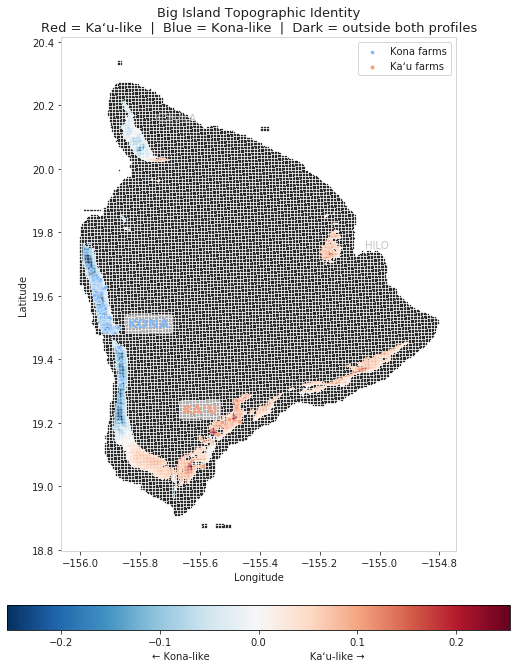

Saved 04_island_identity_map.png
Kaʻu-like: 4.8%   Kona-like: 3.8%   Neither: 91.3% of Big Island land


In [5]:
# ── C3: Island-wide identity map ─────────────────────────────────────────────
from matplotlib.colors import DivergingNorm

fig, ax = plt.subplots(figsize=(13, 10))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.set_aspect(1 / np.cos(np.radians(19.6)))  # geographic aspect at ~19.6°N

# Plot out-of-range cells first as a dark neutral color
out_of_range = np.isnan(identity_isl_masked)
ax.scatter(
    lon_flat[out_of_range], lat_flat[out_of_range],
    c='#2a2a2a', s=2, linewidths=0, rasterized=True, zorder=1,
)

# Plot scored cells on top
in_range = ~out_of_range
vmax = np.nanpercentile(np.abs(identity_isl_masked), 97)
sc = ax.scatter(
    lon_flat[in_range], lat_flat[in_range],
    c=identity_isl_masked[in_range],
    cmap='RdBu_r',
    norm=DivergingNorm(vcenter=0, vmin=-vmax, vmax=vmax),
    s=2, linewidths=0, rasterized=True, zorder=2,
)

# Re-extract coffee lon/lat from UTM centroids
tr_inv = Transformer.from_crs('EPSG:32604', 'EPSG:4326', always_xy=True)
lon_coffee_ok, lat_coffee_ok = tr_inv.transform(cx_utm, cy_utm)

ax.scatter(lon_coffee_ok[kona_isl_mask], lat_coffee_ok[kona_isl_mask],
           c='#7eb8f7', s=14, zorder=5, linewidths=0.3, edgecolors='white',
           label='Kona farms')
ax.scatter(lon_coffee_ok[kau_isl_mask],  lat_coffee_ok[kau_isl_mask],
           c='#f7a07e', s=18, zorder=5, linewidths=0.3, edgecolors='white',
           label="Kaʻu farms")

ax.text(-155.7, 19.5, 'KONA',
        color='#7eb8f7', fontsize=13, fontweight='bold', alpha=0.95,
        ha='right',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='#f5f5f5', alpha=0.65, edgecolor='none'))
ax.text(-155.60, 19.23, "KAʻU",
        color='#f7a07e', fontsize=13, fontweight='bold', alpha=0.95,
        ha='center',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='#f5f5f5', alpha=0.65, edgecolor='none'))
ax.text(-155.05, 19.75, 'HILO',   color='#aaaaaa', fontsize=10, alpha=0.7)
ax.text(-155.75, 20.15, 'KOHALA', color='#aaaaaa', fontsize=10, alpha=0.7)

cbar = fig.colorbar(sc, ax=ax, orientation='horizontal', shrink=0.55, pad=0.08)
cbar.set_label('← Kona-like                                Kaʻu-like →',
               color='#222222', fontsize=10)
cbar.ax.tick_params(colors='#222222')

legend = ax.legend(facecolor='white', framealpha=0.8, loc='upper right')
for text in legend.get_texts():
    text.set_color('#222222')

ax.set_title(
    'Big Island Topographic Identity\nRed = Kaʻu-like  |  Blue = Kona-like  |  Dark = outside both profiles',
    color='#222222', fontsize=13,
)
ax.set_xlabel('Longitude', color='#222222')
ax.set_ylabel('Latitude',  color='#222222')
ax.tick_params(colors='#222222')
for spine in ax.spines.values():
    spine.set_edgecolor('#cccccc')

plt.tight_layout()
plt.savefig(f'{IMG}/04_island_identity_map.png', dpi=150, facecolor=BG, bbox_inches='tight')
plt.show()
print('Saved 04_island_identity_map.png')
print(f"Kaʻu-like: {n_kau/n_land_total*100:.1f}%   "
      f"Kona-like: {n_kona/n_land_total*100:.1f}%   "
      f"Neither: {n_neither/n_land_total*100:.1f}% of Big Island land")

## Part D — Climate-Forward Thermal Projections

Kona and Kaʻu are treated as **separate thermal niches**.
Each region's Gaussian thermal envelope is fitted to its own farm cells,
reflecting the distinct elevation-climate space each currently occupies.
Both projections use the same ensemble ΔT but apply it to different baselines.


In [6]:
# ── D1: Climate ΔT + regional thermal envelopes ─────────────────────────────
# Kona and Kaʻu have distinct elevation profiles and therefore distinct
# thermal optima. We fit separate Gaussian envelopes for each region.
import os
from sklearn.linear_model import LinearRegression

SCENARIOS = ['ssp245', 'ssp585']
HORIZONS  = ['2035', '2045']

baseline_clim = pd.read_pickle(f'{DATA}/plot_climate_features.pkl')

delta_t_all = {}
for s in SCENARIOS:
    delta_t_all[s] = {}
    for h in HORIZONS:
        path = f'{DATA}/plot_climate_features_{s}_{h}.pkl'
        if not os.path.exists(path): continue
        fut = pd.read_pickle(path)
        m = baseline_clim[['plot_id','temp_mean']].merge(
                fut[['plot_id','temp_mean']], on='plot_id', suffixes=('_b','_f'))
        delta_t_all[s][h] = float((m['temp_mean_f'] - m['temp_mean_b']).mean())

dt_2035 = np.mean([delta_t_all[s]['2035'] for s in SCENARIOS if '2035' in delta_t_all.get(s,{})])
dt_2045 = np.mean([delta_t_all[s]['2045'] for s in SCENARIOS if '2045' in delta_t_all.get(s,{})])
print(f'Ensemble ΔT  2035: +{dt_2035:.2f} °C  |  2045: +{dt_2045:.2f} °C')

# Shared lapse rate from all coffee cells
coffee_cc   = coffee[['elev_mean','temp_mean']].dropna()
lapse_model = LinearRegression().fit(
    coffee_cc[['elev_mean']].values, coffee_cc['temp_mean'].values)
print(f'Lapse rate: {lapse_model.coef_[0]*1000:.2f} °C/km')

# Regional thermal envelopes
kona_cc = coffee[coffee['region']=='kona'][['temp_mean']].dropna()
kau_cc  = coffee[coffee['region']=='kau' ][['temp_mean']].dropna()

T_MU_KONA   = float(kona_cc['temp_mean'].mean())
T_SIG_KONA  = float(kona_cc['temp_mean'].std()) * 1.5
T_MU_KAU    = float(kau_cc['temp_mean'].mean())
T_SIG_KAU   = float(kau_cc['temp_mean'].std()) * 1.5

print(f'Kona thermal optimum: {T_MU_KONA:.2f} °C  (σ = {T_SIG_KONA:.2f} °C,  n={len(kona_cc)})')
print(f'Kaʻu thermal optimum: {T_MU_KAU:.2f} °C  (σ = {T_SIG_KAU:.2f} °C,  n={len(kau_cc)})')

def temp_suit_kona(temp_arr, dt=0.0):
    return np.exp(-0.5 * ((temp_arr + dt - T_MU_KONA) / T_SIG_KONA) ** 2)

def temp_suit_kau(temp_arr, dt=0.0):
    return np.exp(-0.5 * ((temp_arr + dt - T_MU_KAU) / T_SIG_KAU) ** 2)


Ensemble ΔT  2035: +1.00 °C  |  2045: +1.35 °C
Lapse rate: -0.89 °C/km
Kona thermal optimum: 18.37 °C  (σ = 1.39 °C,  n=258)
Kaʻu thermal optimum: 19.99 °C  (σ = 2.10 °C,  n=59)


In [7]:
farm_labels = [
    ('KONA',    -155.72, 19.50, '#7eb8f7'),
    ('KAʻU', -155.60, 19.23, '#f7a07e'),
    ('HILO',    -155.05, 19.75, '#aaaaaa'),
    ('KOHALA',  -155.75, 20.15, '#aaaaaa'),
]

def add_overlays(ax, highlight=None):
    """Plot farm dots. highlight='kona' or 'kau' enlarges that region."""
    kona_s = 20 if highlight=='kona' else 12
    kau_s  = 20 if highlight=='kau'  else 12
    ax.scatter(lon_coffee_ok[kona_isl_mask], lat_coffee_ok[kona_isl_mask],
               c='#7eb8f7', s=kona_s, zorder=5, linewidths=0.3, edgecolors='white')
    ax.scatter(lon_coffee_ok[kau_isl_mask],  lat_coffee_ok[kau_isl_mask],
               c='#f7a07e', s=kau_s,  zorder=5, linewidths=0.3, edgecolors='white')
    for txt, x, y, col in farm_labels:
        ax.text(x, y, txt, color=col, fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='#f5f5f5',
                          alpha=0.65, edgecolor='none'))

def add_contours(ax):
    dem_masked = np.where(land_mask, dem_500, np.nan)
    cs = ax.contour(lon_isl, lat_isl, dem_masked,
                    levels=[500,1000,1500,2000,2500,3000],
                    colors='#222222', linewidths=0.5, alpha=0.4, zorder=3)
    ax.clabel(cs, fmt='%dm', fontsize=7, colors='#222222', inline=True, inline_spacing=4)

def style_ax(ax, title):
    ax.set_facecolor(BG)
    ax.set_aspect(1 / np.cos(np.radians(19.6)))
    for spine in ax.spines.values(): spine.set_edgecolor('#cccccc')
    ax.set_title(title, color='#222222', fontsize=13, pad=6)
    ax.tick_params(colors='#222222', labelsize=8)
    ax.set_xlabel('Longitude', color='#222222', fontsize=9)
    ax.set_ylabel('Latitude',  color='#222222', fontsize=9)

# Farmability mask (slope <= 25 deg)
slope_flat   = slope_max_isl.ravel()[flat_mask]
farmable_mask = (slope_flat <= 25.0) & (~np.isnan(slope_flat))
elev_flat    = dem_500.ravel()[flat_mask]
temp_flat    = lapse_model.predict(elev_flat.reshape(-1,1)).ravel()
print(f'Farmable cells: {farmable_mask.sum():,} / {len(farmable_mask):,}')


Farmable cells: 40,099 / 42,524


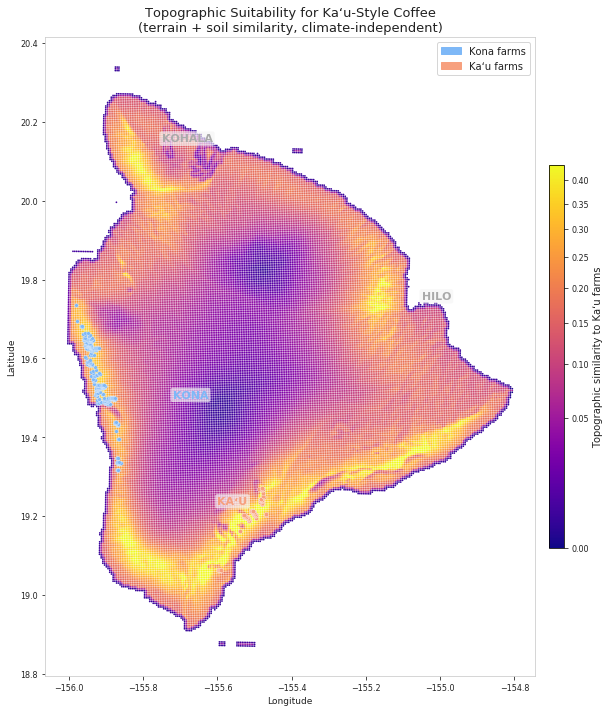

Saved 04_topo_suitability.png


In [8]:
# ── D2: Topographic suitability (static, climate-independent) ─────────
from matplotlib.colors import PowerNorm

ks_min, ks_max = kau_score_isl.min(), kau_score_isl.max()
kau_norm = (kau_score_isl - ks_min) / (ks_max - ks_min)

fig, ax = plt.subplots(figsize=(10, 10))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.set_aspect(1 / np.cos(np.radians(19.6)))
for spine in ax.spines.values():
    spine.set_edgecolor('#cccccc')

vmax_t = float(np.percentile(kau_norm, 99))
sc = ax.scatter(lon_flat, lat_flat, c=kau_norm,
                cmap='plasma',
                norm=PowerNorm(gamma=0.5, vmin=0, vmax=vmax_t),
                s=3, linewidths=0, rasterized=True, zorder=2)

ax.scatter(lon_coffee_ok[kona_isl_mask], lat_coffee_ok[kona_isl_mask],
           c='#7eb8f7', s=14, zorder=5, linewidths=0.3, edgecolors='white')
ax.scatter(lon_coffee_ok[kau_isl_mask],  lat_coffee_ok[kau_isl_mask],
           c='#f7a07e', s=18, zorder=5, linewidths=0.3, edgecolors='white')

for txt, x, y, col in [
    ('KONA',    -155.72, 19.50, '#7eb8f7'),
    ("KA\u02bbU", -155.60, 19.23, '#f7a07e'),
    ('HILO',    -155.05, 19.75, '#aaaaaa'),
    ('KOHALA',  -155.75, 20.15, '#aaaaaa'),
]:
    ax.text(x, y, txt, color=col, fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='#f5f5f5', alpha=0.65, edgecolor='none'))

cb = fig.colorbar(sc, ax=ax, orientation='vertical', shrink=0.6, pad=0.02, aspect=25)
cb.set_label("Topographic similarity to Ka\u02bbu farms", color='#222222', fontsize=10)
cb.ax.tick_params(colors='#222222', labelsize=8)

kona_patch = mpatches.Patch(color='#7eb8f7', label='Kona farms')
kau_patch  = mpatches.Patch(color='#f7a07e', label="Ka\u02bbu farms")
legend = ax.legend(handles=[kona_patch, kau_patch],
                   facecolor='white', framealpha=0.8, loc='upper right')
for t in legend.get_texts(): t.set_color('#222222')

ax.set_title("Topographic Suitability for Ka\u02bbu-Style Coffee\n"
             "(terrain + soil similarity, climate-independent)",
             color='#222222', fontsize=13)
ax.tick_params(colors='#222222', labelsize=8)
ax.set_xlabel('Longitude', color='#222222', fontsize=9)
ax.set_ylabel('Latitude',  color='#222222', fontsize=9)

plt.tight_layout()
plt.savefig(f'{IMG}/04_topo_suitability.png', dpi=150, facecolor=BG, bbox_inches='tight')
plt.show()
print('Saved 04_topo_suitability.png')


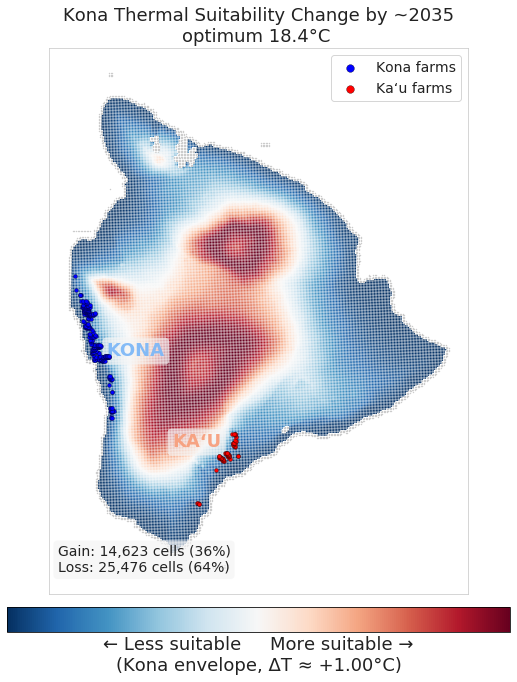

Saved 05_kona_thermal_forward.png


In [9]:
# ── Kona thermal forward — grant style (single panel, 2035) ─────────────────
from matplotlib.colors import DivergingNorm
from pyproj import Transformer

ts_base      = temp_suit_kona(temp_flat, dt=0.0)
td_2035_kona = temp_suit_kona(temp_flat, dt=dt_2035) - ts_base

tr_inv = Transformer.from_crs('EPSG:32604', 'EPSG:4326', always_xy=True)
lon_coffee_ok, lat_coffee_ok = tr_inv.transform(cx_utm, cy_utm)

vlim = float(np.nanpercentile(np.abs(td_2035_kona[farmable_mask]), 99))

fig, ax = plt.subplots(figsize=(13, 10))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.set_aspect(1 / np.cos(np.radians(19.6)))

ax.scatter(lon_flat[~farmable_mask], lat_flat[~farmable_mask],
           c='#cccccc', s=2, linewidths=0, rasterized=True, zorder=1)
sc = ax.scatter(lon_flat[farmable_mask], lat_flat[farmable_mask],
                c=td_2035_kona[farmable_mask], cmap='RdBu_r',
                norm=DivergingNorm(vcenter=0, vmin=-vlim, vmax=vlim),
                s=2, linewidths=0, rasterized=True, zorder=2)

ax.scatter(lon_coffee_ok[kona_isl_mask], lat_coffee_ok[kona_isl_mask],
           c='blue', s=15, zorder=5, linewidths=0.3, edgecolors='k', label='Kona farms')
ax.scatter(lon_coffee_ok[kau_isl_mask], lat_coffee_ok[kau_isl_mask],
           c='red', s=15, zorder=5, linewidths=0.3, edgecolors='k', label="Kaʻu farms")

ax.text(-155.7, 19.50, 'KONA', color='#7eb8f7', fontsize=18, fontweight='bold',
        alpha=0.95, ha='right',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='#f5f5f5', alpha=0.65, edgecolor='none'))
ax.text(-155.60, 19.23, "KAʻU", color='#f7a07e', fontsize=18, fontweight='bold',
        alpha=0.95, ha='center',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='#f5f5f5', alpha=0.65, edgecolor='none'))

td_farm = td_2035_kona[farmable_mask]
n_gain = (td_farm > 0).sum(); n_loss = (td_farm < 0).sum()
ax.text(0.02, 0.04,
        f'Gain: {n_gain:,} cells ({n_gain/len(td_farm)*100:.0f}%)\n'
        f'Loss: {n_loss:,} cells ({n_loss/len(td_farm)*100:.0f}%)',
        transform=ax.transAxes, color='#222222', fontsize=14,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#f5f5f5', alpha=0.7, edgecolor='none'))

cbar = fig.colorbar(sc, ax=ax, orientation='horizontal', shrink=0.55, pad=0.02)
cbar.set_label(
    f'← Less suitable     More suitable →\n(Kona envelope, ΔT ≈ +{dt_2035:.2f}°C)',
    color='#222222', fontsize=18)
cbar.set_ticks([])

legend = ax.legend(facecolor='white', framealpha=0.8, loc='upper right', fontsize=14)
for text in legend.get_texts(): text.set_color('#222222')
for handle in legend.legendHandles: handle.set_sizes([60])

ax.set_title(
    f'Kona Thermal Suitability Change by ~2035\n'
    f'optimum {T_MU_KONA:.1f}°C ',
    color='#222222', fontsize=18)
ax.set_xlabel(''); ax.set_ylabel('')
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values(): spine.set_edgecolor('#cccccc')

plt.tight_layout()
plt.savefig(f'{IMG}/05_kona_thermal_forward.png', dpi=150, facecolor=BG, bbox_inches='tight')
plt.show()
print('Saved 05_kona_thermal_forward.png')

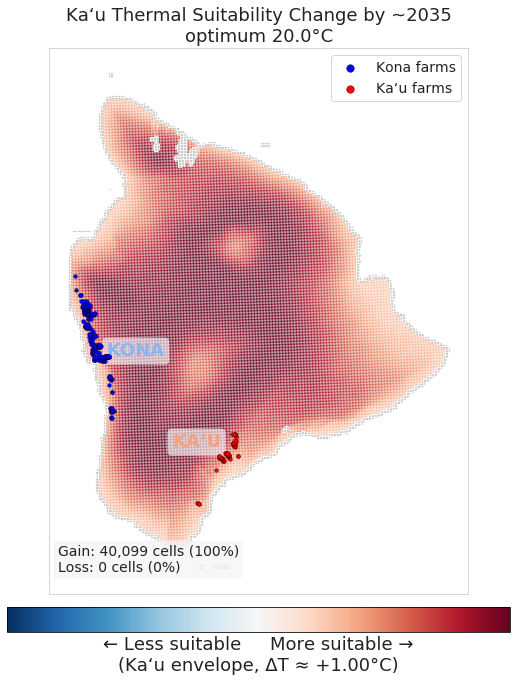

Saved 05_kau_thermal_forward.png


In [10]:
# ── Kaʻu thermal forward — grant style (single panel, 2035) ──────────────────
from matplotlib.colors import DivergingNorm

ts_base     = temp_suit_kau(temp_flat, dt=0.0)
td_2035_kau = temp_suit_kau(temp_flat, dt=dt_2035) - ts_base

vlim = float(np.nanpercentile(np.abs(td_2035_kau[farmable_mask]), 99))

fig, ax = plt.subplots(figsize=(13, 10))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.set_aspect(1 / np.cos(np.radians(19.6)))

ax.scatter(lon_flat[~farmable_mask], lat_flat[~farmable_mask],
           c='#cccccc', s=2, linewidths=0, rasterized=True, zorder=1)
sc = ax.scatter(lon_flat[farmable_mask], lat_flat[farmable_mask],
                c=td_2035_kau[farmable_mask], cmap='RdBu_r',
                norm=DivergingNorm(vcenter=0, vmin=-vlim, vmax=vlim),
                s=2, linewidths=0, rasterized=True, zorder=2)

ax.scatter(lon_coffee_ok[kona_isl_mask], lat_coffee_ok[kona_isl_mask],
           c='blue', s=15, zorder=5, linewidths=0.3, edgecolors='k', label='Kona farms')
ax.scatter(lon_coffee_ok[kau_isl_mask], lat_coffee_ok[kau_isl_mask],
           c='red', s=15, zorder=5, linewidths=0.3, edgecolors='k', label="Kaʻu farms")

ax.text(-155.7, 19.50, 'KONA', color='#7eb8f7', fontsize=18, fontweight='bold',
        alpha=0.95, ha='right',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='#f5f5f5', alpha=0.65, edgecolor='none'))
ax.text(-155.60, 19.23, "KAʻU", color='#f7a07e', fontsize=18, fontweight='bold',
        alpha=0.95, ha='center',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='#f5f5f5', alpha=0.65, edgecolor='none'))

td_farm = td_2035_kau[farmable_mask]
n_gain = (td_farm > 0).sum(); n_loss = (td_farm < 0).sum()
ax.text(0.02, 0.04,
        f'Gain: {n_gain:,} cells ({n_gain/len(td_farm)*100:.0f}%)\n'
        f'Loss: {n_loss:,} cells ({n_loss/len(td_farm)*100:.0f}%)',
        transform=ax.transAxes, color='#222222', fontsize=14,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#f5f5f5', alpha=0.7, edgecolor='none'))

cbar = fig.colorbar(sc, ax=ax, orientation='horizontal', shrink=0.55, pad=0.02)
cbar.set_label(
    f'← Less suitable     More suitable →\n(Kaʻu envelope, ΔT ≈ +{dt_2035:.2f}°C)',
    color='#222222', fontsize=18)
cbar.set_ticks([])

legend = ax.legend(facecolor='white', framealpha=0.8, loc='upper right', fontsize=14)
for text in legend.get_texts(): text.set_color('#222222')
for handle in legend.legendHandles: handle.set_sizes([60])

ax.set_title(
    f"Kaʻu Thermal Suitability Change by ~2035\n"
    f'optimum {T_MU_KAU:.1f}°C',
    color='#222222', fontsize=18)
ax.set_xlabel(''); ax.set_ylabel('')
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values(): spine.set_edgecolor('#cccccc')

plt.tight_layout()
plt.savefig(f'{IMG}/05_kau_thermal_forward.png', dpi=150, facecolor=BG, bbox_inches='tight')
plt.show()
print('Saved 05_kau_thermal_forward.png')

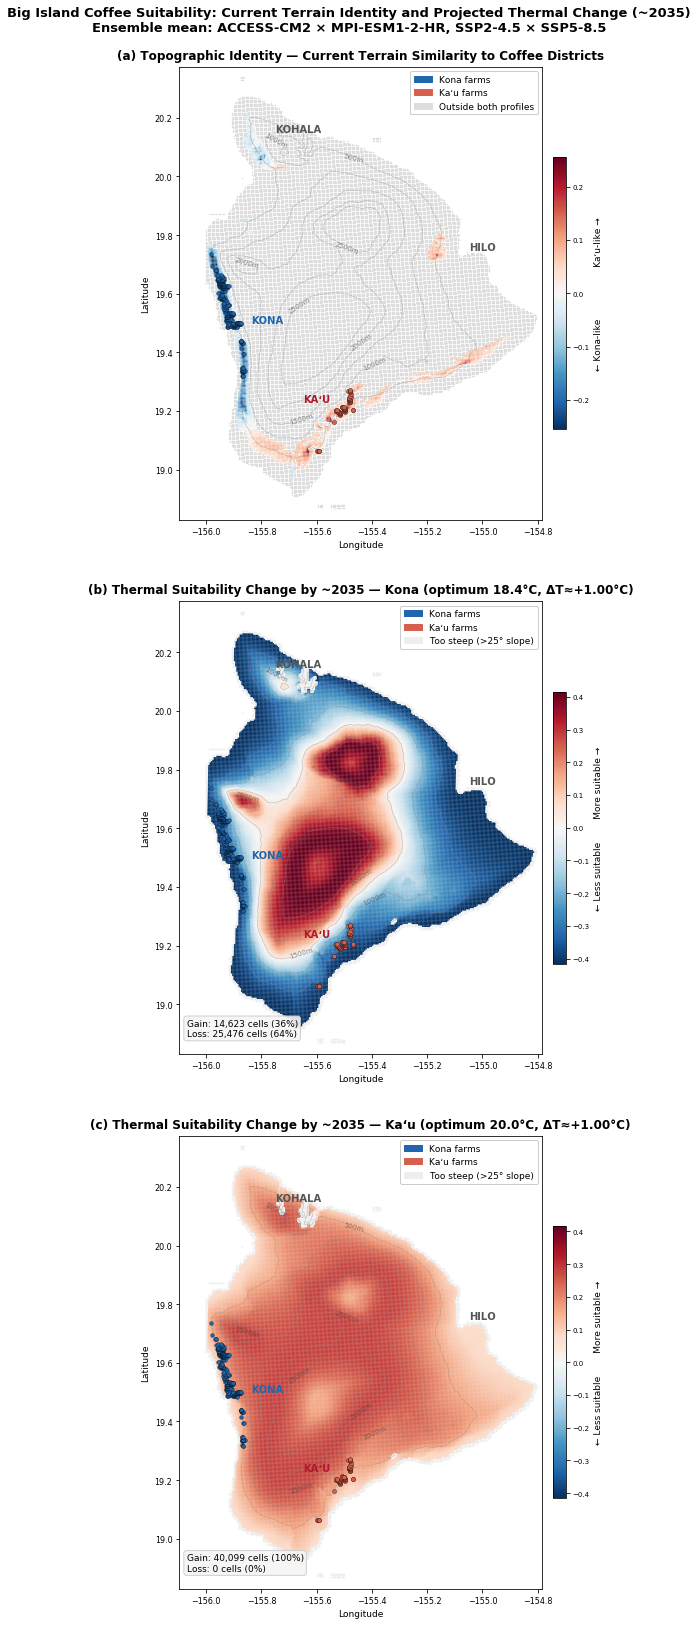

Saved 05_kawabata_summary.png


In [11]:
# ── D5: Kawabata summary — 3-panel, white background (publication style) ──────
from matplotlib.colors import DivergingNorm
from pyproj import Transformer
import matplotlib as mpl

WH = 'white'

elev_f  = dem_500.ravel()[flat_mask]
temp_f  = lapse_model.predict(elev_f.reshape(-1, 1)).ravel()
slope_f = slope_max_isl.ravel()[flat_mask]
farm_msk = (slope_f <= 25.0) & (~np.isnan(slope_f))

def masked(arr, msk):
    out = arr.copy().astype(float); out[~msk] = np.nan; return out

kona_base = temp_suit_kona(temp_f, dt=0.0)
kona_d35  = masked(temp_suit_kona(temp_f, dt=dt_2035) - kona_base, farm_msk)
kau_base  = temp_suit_kau(temp_f,  dt=0.0)
kau_d35   = masked(temp_suit_kau(temp_f,  dt=dt_2035) - kau_base,  farm_msk)

fig, axes = plt.subplots(3, 1, figsize=(10, 28),
                         gridspec_kw={'hspace': 0.18})
fig.patch.set_facecolor(WH)

def base_ax(ax):
    ax.set_facecolor(WH)
    ax.set_aspect(1 / np.cos(np.radians(19.6)))
    for sp in ax.spines.values():
        sp.set_edgecolor('black'); sp.set_linewidth(0.8)
    ax.tick_params(colors='black', labelsize=8)
    ax.set_xlabel('Longitude', color='black', fontsize=9)
    ax.set_ylabel('Latitude',  color='black', fontsize=9)

def add_labels(ax):
    ax.scatter(lon_coffee_ok[kona_isl_mask], lat_coffee_ok[kona_isl_mask],
               c='#2166ac', s=14, zorder=5, linewidths=0.3, edgecolors='black')
    ax.scatter(lon_coffee_ok[kau_isl_mask],  lat_coffee_ok[kau_isl_mask],
               c='#d6604d', s=18, zorder=5, linewidths=0.3, edgecolors='black')
    for txt, x, y, col, ha in [
        ('KONA',    -155.72, 19.50, '#2166ac', 'right'),
        ('KAʻU', -155.60, 19.23, '#b2182b', 'center'),
        ('HILO',    -155.05, 19.75, '#555555', 'left'),
        ('KOHALA',  -155.75, 20.15, '#555555', 'left'),
    ]:
        ax.text(x, y, txt, color=col, fontsize=10, fontweight='bold', ha=ha)

def add_contours(ax):
    dem_mc = np.where(land_mask, dem_500, np.nan)
    cs = ax.contour(lon_isl, lat_isl, dem_mc,
                    levels=[500,1000,1500,2000,2500],
                    colors='#888888', linewidths=0.5, alpha=0.6, zorder=3)
    ax.clabel(cs, fmt='%dm', fontsize=7, colors='#444444',
              inline=True, inline_spacing=4)

def add_legend(ax, extra_handle=None):
    kona_p = mpatches.Patch(color='#2166ac', label='Kona farms')
    kau_p  = mpatches.Patch(color='#d6604d', label='Kaʻu farms')
    handles = [kona_p, kau_p]
    if extra_handle: handles.append(extra_handle)
    leg = ax.legend(handles=handles, facecolor='white', edgecolor='#cccccc',
                    framealpha=1.0, loc='upper right', fontsize=9)
    for t in leg.get_texts(): t.set_color('black')

# ── Row 1: topographic identity ───────────────────────────────────────────────
ax = axes[0]
base_ax(ax)
ax.set_title('(a) Topographic Identity — Current Terrain Similarity to Coffee Districts',
             color='black', fontsize=12, pad=8, fontweight='bold')

out_rng = np.isnan(identity_isl_masked)
ax.scatter(lon_flat[out_rng], lat_flat[out_rng],
           c='#dddddd', s=2, linewidths=0, rasterized=True, zorder=1)
in_rng  = ~out_rng
vmax_id = float(np.nanpercentile(np.abs(identity_isl_masked), 97))
sc0 = ax.scatter(lon_flat[in_rng], lat_flat[in_rng],
                 c=identity_isl_masked[in_rng], cmap='RdBu_r',
                 norm=DivergingNorm(vcenter=0, vmin=-vmax_id, vmax=vmax_id),
                 s=2, linewidths=0, rasterized=True, zorder=2)
add_contours(ax)
add_labels(ax)
cb0 = fig.colorbar(sc0, ax=ax, orientation='vertical', shrink=0.6, pad=0.02, aspect=22)
cb0.set_label('← Kona-like                  Kaʻu-like →',
              color='black', fontsize=9)
cb0.ax.tick_params(colors='black', labelsize=7)
dark_p = mpatches.Patch(color='#dddddd', label='Outside both profiles')
add_legend(ax, dark_p)

# ── Rows 2 & 3: 2035 thermal change ───────────────────────────────────────────
vlim = float(np.nanpercentile(
    np.abs(np.concatenate([kona_d35[~np.isnan(kona_d35)],
                           kau_d35[~np.isnan(kau_d35)]])), 99))

for ax, td, region, T_MU, panel_lbl in [
    (axes[1], kona_d35, 'Kona', T_MU_KONA, 'b'),
    (axes[2], kau_d35,  'Kaʻu', T_MU_KAU,  'c'),
]:
    base_ax(ax)
    ax.set_title(
        f'({panel_lbl}) Thermal Suitability Change by ~2035 — {region} '
        f'(optimum {T_MU:.1f}°C, ΔT≈+{dt_2035:.2f}°C)',
        color='black', fontsize=12, pad=8, fontweight='bold')
    ax.scatter(lon_flat, lat_flat, c='#eeeeee', s=3,
               linewidths=0, rasterized=True, zorder=1)
    sc = ax.scatter(lon_flat, lat_flat, c=td, cmap='RdBu_r',
                    norm=DivergingNorm(vcenter=0, vmin=-vlim, vmax=vlim),
                    s=3, linewidths=0, rasterized=True, zorder=2)
    add_contours(ax)
    add_labels(ax)
    cb = fig.colorbar(sc, ax=ax, orientation='vertical', shrink=0.6, pad=0.02, aspect=22)
    cb.set_label('← Less suitable        More suitable →',
                 color='black', fontsize=9)
    cb.ax.tick_params(colors='black', labelsize=7)
    td_farm = td[farm_msk]
    n_gain = (td_farm > 0).sum(); n_loss = (td_farm < 0).sum()
    ax.text(0.02, 0.04,
            f'Gain: {n_gain:,} cells ({n_gain/len(td_farm)*100:.0f}%)\n'
            f'Loss: {n_loss:,} cells ({n_loss/len(td_farm)*100:.0f}%)',
            transform=ax.transAxes, color='black', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#f5f5f5',
                      alpha=0.9, edgecolor='#cccccc'))
    excl_p = mpatches.Patch(color='#eeeeee', label='Too steep (>25° slope)')
    add_legend(ax, excl_p)

fig.suptitle(
    'Big Island Coffee Suitability: Current Terrain Identity and Projected Thermal Change (~2035)\n'
    'Ensemble mean: ACCESS-CM2 × MPI-ESM1-2-HR, SSP2-4.5 × SSP5-8.5',
    color='black', fontsize=13, fontweight='bold', y=0.91)
plt.savefig(f'{IMG}/05_kawabata_summary.png', dpi=150,
            facecolor=WH, bbox_inches='tight')
plt.show()
print('Saved 05_kawabata_summary.png')


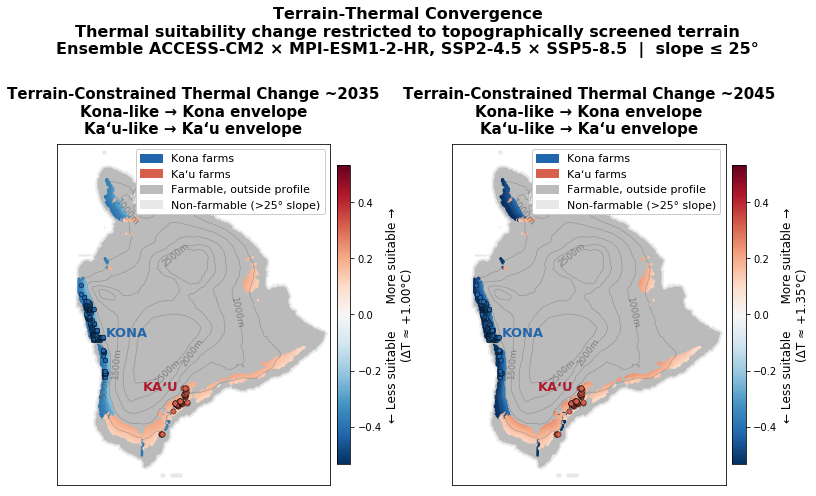

Saved 06_topo_thermal_convergence.png


In [12]:
# ── E1: Terrain-Thermal Convergence Overlay ──────────────────────────────────
# For each farmable grid cell that passes the topographic profile screen,
# show thermal suitability change matched to its regional envelope:
#   Kona-like terrain → Kona ΔS;  Kaʻu-like terrain → Kaʻu ΔS
# Cells outside both profiles: mid-grey.  Steep / non-farmable: light grey.

from matplotlib.colors import DivergingNorm
import matplotlib.patches as mpatches

# ── Compute 2045 thermal deltas (2035 already in D5 scope) ───────────────────
kona_d45 = masked(temp_suit_kona(temp_f, dt=dt_2045) - kona_base, farm_msk)
kau_d45  = masked(temp_suit_kau(temp_f,  dt=dt_2045) - kau_base,  farm_msk)

def make_combined_delta(kona_d, kau_d):
    combined   = np.full(len(lon_flat), np.nan)
    topo_valid = ~np.isnan(identity_isl_masked)
    kona_like  = topo_valid & (identity_isl_masked <= 0) & farm_msk & ~np.isnan(kona_d)
    kau_like   = topo_valid & (identity_isl_masked >  0) & farm_msk & ~np.isnan(kau_d)
    combined[kona_like] = kona_d[kona_like]
    combined[kau_like]  = kau_d[kau_like]
    return combined

comb_d35 = make_combined_delta(kona_d35, kau_d35)
comb_d45 = make_combined_delta(kona_d45, kau_d45)

all_vals = np.concatenate([comb_d35[~np.isnan(comb_d35)],
                           comb_d45[~np.isnan(comb_d45)]])
vlim = float(np.nanpercentile(np.abs(all_vals), 99))

# ── 2-row stacked layout ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 10),
                         gridspec_kw={'hspace': 0.28})
fig.patch.set_facecolor('white')

FS = dict(title=15, label=12, tick=10, annot=11, legend=11, contour=9, region=13)

for ax, comb_d, horizon, dt in [
    (axes[0], comb_d35, '2035', dt_2035),
    (axes[1], comb_d45, '2045', dt_2045),
]:
    ax.set_facecolor('white')
    ax.set_aspect(1 / np.cos(np.radians(19.6)))
    for sp in ax.spines.values():
        sp.set_edgecolor('black'); sp.set_linewidth(0.8)

    # Layer 1: all land — light grey background
    ax.scatter(lon_flat, lat_flat, c='#e8e8e8', s=4,
               linewidths=0, rasterized=True, zorder=1)

    # Layer 2: farmable but outside topographic profile — mid-grey
    outside = farm_msk & np.isnan(identity_isl_masked)
    ax.scatter(lon_flat[outside], lat_flat[outside],
               c='#bbbbbb', s=4, linewidths=0, rasterized=True, zorder=2)

    # Layer 3: topographically screened — coloured by thermal change
    in_range = ~np.isnan(comb_d)
    sc = ax.scatter(lon_flat[in_range], lat_flat[in_range],
                    c=comb_d[in_range], cmap='RdBu_r',
                    norm=DivergingNorm(vcenter=0, vmin=-vlim, vmax=vlim),
                    s=6, linewidths=0, rasterized=True, zorder=3)

    # Elevation contours
    dem_mc = np.where(land_mask, dem_500, np.nan)
    cs = ax.contour(lon_isl, lat_isl, dem_mc,
                    levels=[500, 1000, 1500, 2000, 2500],
                    colors='#666666', linewidths=0.6, alpha=0.5, zorder=4)
    ax.clabel(cs, fmt='%dm', fontsize=FS['contour'], colors='#444444',
              inline=True, inline_spacing=4)

    # Farm locations
    ax.scatter(lon_coffee_ok[kona_isl_mask], lat_coffee_ok[kona_isl_mask],
               c='#2166ac', s=22, zorder=6, linewidths=0.4, edgecolors='black')
    ax.scatter(lon_coffee_ok[kau_isl_mask],  lat_coffee_ok[kau_isl_mask],
               c='#d6604d', s=28, zorder=6, linewidths=0.4, edgecolors='black')

    # Region labels
    for txt, x, y, col, ha in [
        ('KONA',   -155.66, 19.50, '#2166ac', 'right'),
        ("KAʻU",   -155.60, 19.26, '#b2182b', 'center'),
        # ('HILO',   -155.05, 19.73, '#555555', 'left'),
        # ('KOHALA', -155.75, 20.15, '#555555', 'left'),
    ]:
        ax.text(x, y, txt, color=col, fontsize=FS['region'],
                fontweight='bold', ha=ha)

    # Stats annotation
    n_topo = int(in_range.sum())
    n_gain = int((comb_d[in_range] > 0).sum())
    n_loss = int((comb_d[in_range] < 0).sum())
    # ax.text(0.02, 0.04,
    #         f'Terrain-screened: {n_topo:,} cells\n'
    #         f'Thermal gain: {n_gain:,} ({n_gain/n_topo*100:.0f}%)\n'
    #         f'Thermal loss: {n_loss:,} ({n_loss/n_topo*100:.0f}%)',
    #         transform=ax.transAxes, color='black', fontsize=FS['annot'],
    #         bbox=dict(boxstyle='round,pad=0.4', facecolor='#f5f5f5',
    #                   alpha=0.9, edgecolor='#cccccc'))

    cb = fig.colorbar(sc, ax=ax, orientation='vertical',
                      shrink=0.55, pad=0.02, aspect=22)
    cb.set_label(f'← Less suitable       More suitable →\n'
                 f'(ΔT ≈ +{dt:.2f}°C)',
                 color='black', fontsize=FS['label'])
    cb.ax.tick_params(colors='black', labelsize=FS['tick'])

    ax.set_title(
        f'Terrain-Constrained Thermal Change ~{horizon}\n'
        f'Kona-like → Kona envelope\nKaʻu-like → Kaʻu envelope',
        color='black', fontsize=FS['title'], fontweight='bold', pad=10)
    ax.set_xticks([])
    ax.set_yticks([])

    kona_p  = mpatches.Patch(color='#2166ac', label='Kona farms')
    kau_p   = mpatches.Patch(color='#d6604d', label="Kaʻu farms")
    out_p   = mpatches.Patch(color='#bbbbbb', label='Farmable, outside profile')
    steep_p = mpatches.Patch(color='#e8e8e8', label='Non-farmable (>25° slope)')
    leg = ax.legend(handles=[kona_p, kau_p, out_p, steep_p],
                    facecolor='white', edgecolor='#cccccc',
                    framealpha=1.0, loc='upper right', fontsize=FS['legend'])
    for t in leg.get_texts(): t.set_color('black')

fig.suptitle(
    'Terrain-Thermal Convergence\n'
    'Thermal suitability change restricted to topographically screened terrain\n'
    'Ensemble ACCESS-CM2 × MPI-ESM1-2-HR, SSP2-4.5 × SSP5-8.5  |  slope ≤ 25°',
    color='black', fontsize=16, fontweight='bold', y=0.93)

plt.savefig(f'{IMG}/06_topo_thermal_convergence.png', dpi=150,
            facecolor='white', bbox_inches='tight')
plt.show()
print('Saved 06_topo_thermal_convergence.png')


 90.0th pct | thresh=3.342 | Kona 2.80% | Ka'u 2.29% | J_kona=0.730 | J_kau=0.472
 92.5th pct | thresh=3.859 | Kona 3.52% | Ka'u 4.14% | J_kona=0.918 | J_kau=0.854
 95.0th pct | thresh=4.060 | Kona 3.83% | Ka'u 4.85% | J_kona=1.000 | J_kau=1.000
 97.5th pct | thresh=4.502 | Kona 4.43% | Ka'u 6.39% | J_kona=0.864 | J_kau=0.759


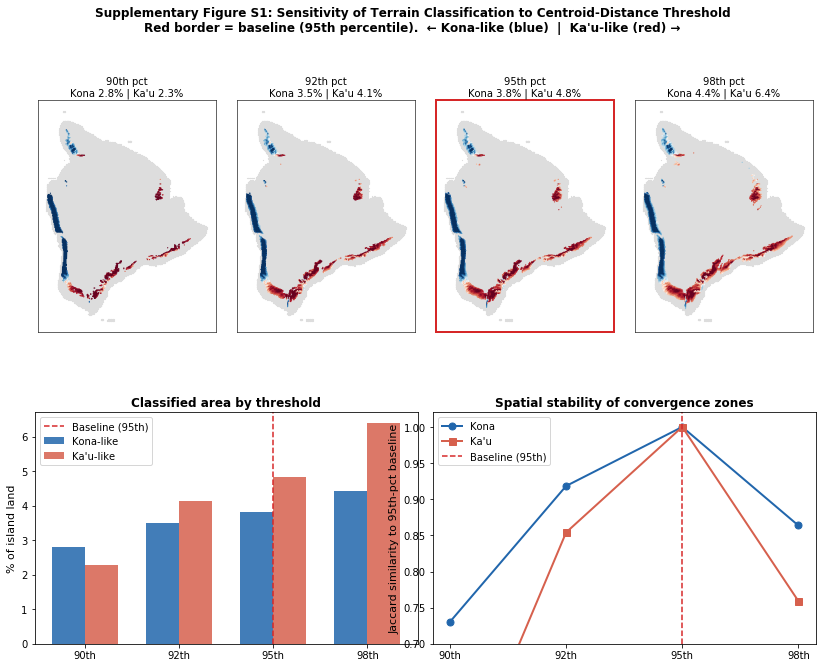

Saved S1_threshold_sensitivity.png


In [13]:
# ── E2: Sensitivity analysis — centroid-distance threshold ────────────────────
# Tests whether the 95th-percentile topographic screen is robust.
# Recomputes Kona-like / Ka'u-like classification at four thresholds,
# reports area fractions and Jaccard similarity vs the 95th-pct baseline,
# and saves a supplementary figure.

THRESHOLDS_PCT = [90, 92.5, 95, 97.5]

# ── Compute baseline (95th pct) first so Jaccard is always defined ─────────────
thresh_95  = np.percentile(np.concatenate([kona_dists, kau_dists]), 95)
in_95      = (dist_kona_isl <= thresh_95) | (dist_kau_isl <= thresh_95)
ident_95   = np.where(in_95, identity_isl, np.nan)
baseline_kona = (~np.isnan(ident_95)) & (ident_95 <= 0)
baseline_kau  = (~np.isnan(ident_95)) & (ident_95 >  0)

results = []
for pct in THRESHOLDS_PCT:
    thresh = np.percentile(np.concatenate([kona_dists, kau_dists]), pct)
    in_rng = (dist_kona_isl <= thresh) | (dist_kau_isl <= thresh)
    ident  = np.where(in_rng, identity_isl, np.nan)

    kona_px  = np.sum((~np.isnan(ident)) & (ident <= 0))
    kau_px   = np.sum((~np.isnan(ident)) & (ident >  0))
    n_land   = len(ident)
    kona_pct = kona_px / n_land * 100
    kau_pct  = kau_px  / n_land * 100

    this_kona    = (~np.isnan(ident)) & (ident <= 0)
    this_kau     = (~np.isnan(ident)) & (ident >  0)
    jaccard_kona = (this_kona & baseline_kona).sum() / (this_kona | baseline_kona).sum()
    jaccard_kau  = (this_kau  & baseline_kau ).sum() / (this_kau  | baseline_kau ).sum()

    results.append(dict(pct=pct, thresh=thresh,
                        kona_pct=kona_pct, kau_pct=kau_pct,
                        jaccard_kona=jaccard_kona, jaccard_kau=jaccard_kau))
    print(f"{pct:5.1f}th pct | thresh={thresh:.3f} | "
          f"Kona {kona_pct:.2f}% | Ka\'u {kau_pct:.2f}% | "
          f"J_kona={jaccard_kona:.3f} | J_kau={jaccard_kau:.3f}")

# ── Supplementary figure ──────────────────────────────────────────────────────
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 10))
fig.patch.set_facecolor('white')
gs  = gridspec.GridSpec(2, len(THRESHOLDS_PCT),
                        hspace=0.35, wspace=0.08,
                        figure=fig)

vmax_id = float(np.nanpercentile(np.abs(identity_isl[~np.isnan(identity_isl)]), 97))

for col, pct in enumerate(THRESHOLDS_PCT):
    thresh = np.percentile(np.concatenate([kona_dists, kau_dists]), pct)
    in_rng = (dist_kona_isl <= thresh) | (dist_kau_isl <= thresh)
    ident  = np.where(in_rng, identity_isl, np.nan)
    r      = results[col]

    ax = fig.add_subplot(gs[0, col])
    ax.set_facecolor('white')
    ax.set_aspect(1 / np.cos(np.radians(19.6)))
    ax.set_xticks([]); ax.set_yticks([])

    out = np.isnan(ident)
    ax.scatter(lon_flat[out], lat_flat[out], c='#dddddd', s=1.5,
               linewidths=0, rasterized=True)
    inn = ~out
    ax.scatter(lon_flat[inn], lat_flat[inn],
               c=ident[inn], cmap='RdBu_r',
               vmin=-vmax_id, vmax=vmax_id,
               s=1.5, linewidths=0, rasterized=True)

    border_color = '#d62728' if pct == 95 else 'black'
    border_width = 2.0 if pct == 95 else 0.6
    for sp in ax.spines.values():
        sp.set_edgecolor(border_color); sp.set_linewidth(border_width)

    ax.set_title(f'{pct:.0f}th pct\n'
                 f'Kona {r["kona_pct"]:.1f}% | Ka\'u {r["kau_pct"]:.1f}%',
                 fontsize=10, color='black', pad=4)

# ── Bottom row: bar chart + Jaccard ──────────────────────────────────────────
ax_bar  = fig.add_subplot(gs[1, :2])
ax_jacc = fig.add_subplot(gs[1, 2:])

x         = np.arange(len(THRESHOLDS_PCT))
w         = 0.35
kona_area = [r['kona_pct']     for r in results]
kau_area  = [r['kau_pct']      for r in results]
j_kona    = [r['jaccard_kona'] for r in results]
j_kau     = [r['jaccard_kau']  for r in results]

ax_bar.bar(x - w/2, kona_area, w, color='#2166ac', label='Kona-like', alpha=0.85)
ax_bar.bar(x + w/2, kau_area,  w, color='#d6604d', label="Ka\'u-like", alpha=0.85)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels([f'{p:.0f}th' for p in THRESHOLDS_PCT], fontsize=11)
ax_bar.set_ylabel('% of island land', fontsize=11)
ax_bar.set_title('Classified area by threshold', fontsize=12, fontweight='bold')
ax_bar.axvline(x=2, color='#d62728', linestyle='--', linewidth=1.5, label='Baseline (95th)')
ax_bar.legend(fontsize=10, facecolor='white')
ax_bar.set_facecolor('white'); ax_bar.tick_params(labelsize=10)

ax_jacc.plot(x, j_kona, 'o-', color='#2166ac', linewidth=2, markersize=7, label='Kona')
ax_jacc.plot(x, j_kau,  's-', color='#d6604d', linewidth=2, markersize=7, label="Ka\'u")
ax_jacc.axvline(x=2, color='#d62728', linestyle='--', linewidth=1.5, label='Baseline (95th)')
ax_jacc.set_xticks(x)
ax_jacc.set_xticklabels([f'{p:.0f}th' for p in THRESHOLDS_PCT], fontsize=11)
ax_jacc.set_ylabel('Jaccard similarity to 95th-pct baseline', fontsize=11)
ax_jacc.set_ylim(0.7, 1.02)
ax_jacc.set_title('Spatial stability of convergence zones', fontsize=12, fontweight='bold')
ax_jacc.legend(fontsize=10, facecolor='white')
ax_jacc.set_facecolor('white'); ax_jacc.tick_params(labelsize=10)

fig.suptitle(
    "Supplementary Figure S1: Sensitivity of Terrain Classification to Centroid-Distance Threshold\n"
    "Red border = baseline (95th percentile).  ← Kona-like (blue)  |  Ka\'u-like (red) →",
    fontsize=12, fontweight='bold', color='black', y=1.01)

plt.savefig(f'{IMG}/S1_threshold_sensitivity.png', dpi=150,
            facecolor='white', bbox_inches='tight')
plt.show()
print('Saved S1_threshold_sensitivity.png')


In [14]:
# ── E3: Overestimation factor — thermal-only vs terrain-constrained ──────────
# Computes the ratio of thermally-gaining farmable cells to cells that pass
# BOTH the terrain screen AND are thermally gaining.
# This is the quantitative punchline: climate-only models overestimate
# accessible opportunity by this factor.

print("=" * 65)
print("OVERESTIMATION FACTOR: thermal-only vs. terrain-constrained")
print("=" * 65)

n_farmable = int(farm_msk.sum())
topo_valid = ~np.isnan(identity_isl_masked)
kona_like  = topo_valid & (identity_isl_masked <= 0)
kau_like   = topo_valid & (identity_isl_masked >  0)

rows = []
for label, thermal_d, topo_msk, horizon in [
    ("Kona", kona_d35, kona_like, "2035"),
    ("Kona", kona_d45, kona_like, "2045"),
    ("Ka'u", kau_d35,  kau_like,  "2035"),
    ("Ka'u", kau_d45,  kau_like,  "2045"),
]:
    # Thermal-only: farmable + gaining
    therm = farm_msk & ~np.isnan(thermal_d) & (thermal_d > 0)
    n_th  = int(therm.sum())
    p_th  = n_th / n_farmable * 100

    # Dual screen: farmable + topographically matched + gaining
    dual  = farm_msk & topo_msk & ~np.isnan(thermal_d) & (thermal_d > 0)
    n_du  = int(dual.sum())
    p_du  = n_du / n_farmable * 100

    factor = n_th / n_du if n_du > 0 else float("inf")

    rows.append((label, horizon, n_th, p_th, n_du, p_du, factor))
    print(f"\n{label} ~{horizon}:")
    print(f"  Thermal-only gaining (farmable):      {n_th:6,}  ({p_th:5.1f}%)")
    print(f"  Terrain-constrained gaining:          {n_du:6,}  ({p_du:5.1f}%)")
    print(f"  Overestimation factor:                {factor:6.1f}x")

print("\n" + "=" * 65)
print("Copy these numbers into paper.tex Results §5.4")
print("=" * 65)


OVERESTIMATION FACTOR: thermal-only vs. terrain-constrained

Kona ~2035:
  Thermal-only gaining (farmable):      14,623  ( 36.5%)
  Terrain-constrained gaining:               0  (  0.0%)
  Overestimation factor:                   infx

Kona ~2045:
  Thermal-only gaining (farmable):      12,039  ( 30.0%)
  Terrain-constrained gaining:               0  (  0.0%)
  Overestimation factor:                   infx

Ka'u ~2035:
  Thermal-only gaining (farmable):      40,099  (100.0%)
  Terrain-constrained gaining:           2,062  (  5.1%)
  Overestimation factor:                  19.4x

Ka'u ~2045:
  Thermal-only gaining (farmable):      40,099  (100.0%)
  Terrain-constrained gaining:           2,062  (  5.1%)
  Overestimation factor:                  19.4x

Copy these numbers into paper.tex Results §5.4


In [15]:
# ── E4: Overestimation factor across threshold sensitivity range ──────────────
# Cross-walks E3 with the E2 sensitivity analysis.
# Directly addresses R2 concern that the factor may reflect modeling choices:
# shows the factor at every threshold tested, demonstrating the qualitative
# conclusion is robust regardless of threshold choice.

# Thermal-only gaining cells (Ka'u) — numerator, fixed across thresholds
kau_thermal_gaining = farm_msk & ~np.isnan(kau_d35) & (kau_d35 > 0)
n_thermal_kau = int(kau_thermal_gaining.sum())

print("=" * 65)
print("OVERESTIMATION FACTOR SENSITIVITY — Ka'u")
print(f"Thermal-only gaining cells (fixed): {n_thermal_kau:,}")
print("=" * 65)
print(f"{'Threshold':>12} | {'Terrain cells':>14} | {'Factor':>8}")
print("-" * 44)

factor_rows = []
for pct in THRESHOLDS_PCT:
    thresh  = np.percentile(np.concatenate([kona_dists, kau_dists]), pct)
    in_rng  = (dist_kona_isl <= thresh) | (dist_kau_isl <= thresh)
    ident   = np.where(in_rng, identity_isl, np.nan)
    kau_msk = farm_msk & (~np.isnan(ident)) & (ident > 0)
    dual    = kau_msk & ~np.isnan(kau_d35) & (kau_d35 > 0)
    n_du    = int(dual.sum())
    factor  = n_thermal_kau / n_du if n_du > 0 else float('inf')
    marker  = "  <- baseline" if pct == 95 else ""
    print(f"  {pct:>5.1f}th pct | {n_du:>14,} | {factor:>7.1f}x{marker}")
    factor_rows.append((pct, n_du, factor))

print("-" * 44)
f_vals = [r[2] for r in factor_rows]
print(f"Factor range: {min(f_vals):.1f}x - {max(f_vals):.1f}x")
print("Order-of-magnitude overestimation holds at every threshold tested.")


OVERESTIMATION FACTOR SENSITIVITY — Ka'u
Thermal-only gaining cells (fixed): 40,099
   Threshold |  Terrain cells |   Factor
--------------------------------------------
   90.0th pct |            974 |    41.2x
   92.5th pct |          1,761 |    22.8x
   95.0th pct |          2,062 |    19.4x  <- baseline
   97.5th pct |          2,716 |    14.8x
--------------------------------------------
Factor range: 14.8x - 41.2x
Order-of-magnitude overestimation holds at every threshold tested.


In [16]:
# ── E5: Mahalanobis vs Euclidean distance metric comparison ──────────────────
# Addresses R2 concern: justify Euclidean distance in standardised feature space.
# Computes Mahalanobis distance using pooled within-class covariance, applies
# the same 95th-percentile threshold logic, and compares terrain footprints.
# If Jaccard similarity is high and overestimation factor is similar,
# the Euclidean choice is empirically validated.

from scipy.spatial.distance import cdist

# ── Pooled within-class covariance ───────────────────────────────────────────
kona_centered = Xs_coffee_isl[kona_isl_mask] - kona_isl_centroid
kau_centered  = Xs_coffee_isl[kau_isl_mask]  - kau_isl_centroid
pooled_cov    = np.cov(np.vstack([kona_centered, kau_centered]).T, ddof=1)

# Small regularisation in case of near-singular covariance
pooled_cov_reg = pooled_cov + 1e-6 * np.eye(pooled_cov.shape[0])
VI = np.linalg.inv(pooled_cov_reg)

# ── Mahalanobis distances: island cells to each regional centroid ─────────────
dist_kona_mah = cdist(Xs_isl, kona_isl_centroid.reshape(1, -1),
                      metric='mahalanobis', VI=VI).ravel()
dist_kau_mah  = cdist(Xs_isl, kau_isl_centroid.reshape(1, -1),
                      metric='mahalanobis', VI=VI).ravel()

# ── Within-region farm distances (for threshold calibration) ─────────────────
kona_mah_dists = cdist(Xs_coffee_isl[kona_isl_mask],
                       kona_isl_centroid.reshape(1, -1),
                       metric='mahalanobis', VI=VI).ravel()
kau_mah_dists  = cdist(Xs_coffee_isl[kau_isl_mask],
                       kau_isl_centroid.reshape(1, -1),
                       metric='mahalanobis', VI=VI).ravel()

# ── Apply same threshold range and compare to Euclidean baseline ─────────────
print("=" * 70)
print("MAHALANOBIS vs EUCLIDEAN — terrain footprint and overestimation factor")
print("=" * 70)
print(f"{'Threshold':>12} | {'Kona%':>7} | {'Kaʻu%':>7} | {'J_Kona':>8} | {'J_Kaʻu':>8} | {'Factor':>8}")
print("-" * 62)

# Euclidean 95th pct baseline for Jaccard comparison
thresh_euc95 = np.percentile(np.concatenate([kona_dists, kau_dists]), 95)
in_euc95     = (dist_kona_isl <= thresh_euc95) | (dist_kau_isl <= thresh_euc95)
ident_euc95  = np.where(in_euc95, identity_isl, np.nan)
base_kona_euc = (~np.isnan(ident_euc95)) & (ident_euc95 <= 0)
base_kau_euc  = (~np.isnan(ident_euc95)) & (ident_euc95 >  0)

kau_thermal_gaining = farm_msk & ~np.isnan(kau_d35) & (kau_d35 > 0)
n_thermal_kau = int(kau_thermal_gaining.sum())
n_land = len(identity_isl)

mah_rows = []
for pct in THRESHOLDS_PCT:
    thresh_m  = np.percentile(np.concatenate([kona_mah_dists, kau_mah_dists]), pct)
    in_m      = (dist_kona_mah <= thresh_m) | (dist_kau_mah <= thresh_m)
    # Identity score still uses Euclidean-derived scores (same sign logic)
    ident_m   = np.where(in_m, identity_isl, np.nan)
    kona_m    = (~np.isnan(ident_m)) & (ident_m <= 0)
    kau_m     = (~np.isnan(ident_m)) & (ident_m >  0)
    kona_pct  = kona_m.sum() / n_land * 100
    kau_pct   = kau_m.sum()  / n_land * 100
    j_kona    = (kona_m & base_kona_euc).sum() / (kona_m | base_kona_euc).sum()
    j_kau     = (kau_m  & base_kau_euc ).sum() / (kau_m  | base_kau_euc ).sum()
    dual      = farm_msk & kau_m & ~np.isnan(kau_d35) & (kau_d35 > 0)
    n_du      = int(dual.sum())
    factor    = n_thermal_kau / n_du if n_du > 0 else float('inf')
    marker    = "  <- 95th" if pct == 95 else ""
    print(f"  {pct:>5.1f}th pct | {kona_pct:>6.2f}% | {kau_pct:>6.2f}% | "
          f"{j_kona:>8.3f} | {j_kau:>8.3f} | {factor:>7.1f}x{marker}")
    mah_rows.append((pct, kona_pct, kau_pct, j_kona, j_kau, n_du, factor))

print("-" * 62)
print("Jaccard similarity is vs. Euclidean 95th-pct baseline.")
print("High Jaccard = Mahalanobis recovers the same terrain footprint.")
print("Similar factor = overestimation conclusion is metric-independent.")


MAHALANOBIS vs EUCLIDEAN — terrain footprint and overestimation factor
   Threshold |   Kona% |   Kaʻu% |   J_Kona |   J_Kaʻu |   Factor
--------------------------------------------------------------
   90.0th pct |   2.33% |   0.57% |    0.547 |    0.113 |   165.7x
   92.5th pct |   2.79% |   0.90% |    0.601 |    0.171 |   104.4x
   95.0th pct |   4.55% |   2.97% |    0.681 |    0.334 |    31.7x  <- 95th
   97.5th pct |   5.25% |   4.45% |    0.646 |    0.363 |    21.2x
--------------------------------------------------------------
Jaccard similarity is vs. Euclidean 95th-pct baseline.
High Jaccard = Mahalanobis recovers the same terrain footprint.
Similar factor = overestimation conclusion is metric-independent.
